# 🌍 Hackathon IndabaX Cameroon 2026
## Starter Notebook - Français
### *L'IA au service de la résilience climatique et sanitaire*

---

| Étape | Description |
|-------|-------------|
| **1** | Setup & Chargement des données |
| **2** | Exploration (EDA) |
| **3** | Nettoyage & Feature Engineering |
| **4** | Modélisation Baseline |
| **5** | Pistes pour aller plus loin |

## 📑 Table des matières

- [1. Setup & Chargement](#section-setup)

- [2. Exploration des Données (EDA)](#section-eda)

- [3. Nettoyage & Feature Engineering](#section-cleaning)

- [4. Modélisation Baseline](#section-baseline)

- [Pour aller plus loin](#section-further)

<a id="section-setup"></a>

---
## 1. ⚙️ Setup & Chargement

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px5
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
SEED = 42

In [2]:
# ── Chargement du dataset officiel ───────────────────────────────────────────
df = pd.read_excel('../data/Dataset_complet_Meteo.xlsx')

# Conversion des colonnes numériques (stockées en string dans le fichier)
num_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'latitude', 'longitude'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset : {df.shape[0]:,} obs × {df.shape[1]} variables")
print(f"   Période  : {df['time'].min().date()} → {df['time'].max().date()}")
print(f"   Villes   : {df['city'].nunique()} | Régions : {df['region'].nunique()}")
df.head(3)

Dataset : 87,240 obs × 26 variables
   Période  : 2020-01-01 → 2025-12-20
   Villes   : 40 | Régions : 10


,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,NaN,NaN,34.0,2026-06-25 00:00:00,NaN,2020-01-01 06:22:00,...,0.0,NaN,NaN,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,NaN,NaN,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,NaN,NaN,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,NaN,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,NaN,2020-01-03 06:23:00,...,0.0,NaN,NaN,65,NaN,4.78,Bafia,Centre,4.75,11.23


<a id="section-eda"></a>

---
## 2. 🔍 Exploration des Données (EDA)

In [3]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
df[['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration']].describe().round(2)

,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum,et0_fao_evapotranspiration
count,11508.00,47769.00,9378.00,69898.00,70121.00
mean,26.34,2.11,12.15,18.48,4.19
std,4.97,9.52,3.64,4.05,1.52
min,16.00,0.00,4.00,1.88,0.47
25%,23.00,0.00,10.00,15.87,3.23
50%,25.00,0.00,12.00,19.18,3.91
75%,31.20,0.50,14.00,21.63,4.81
max,38.20,251.10,36.60,26.79,12.31


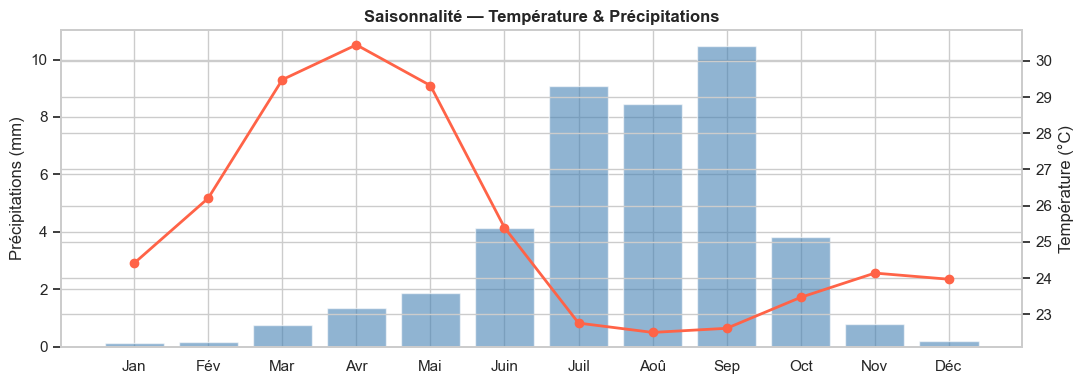

In [4]:
# ── Saisonnalité nationale ────────────────────────────────────────────────────
df['month'] = df['time'].dt.month
monthly = df.groupby('month').agg(
    temp_moy=('temperature_2m_mean', 'mean'),
    pluie_moy=('precipitation_sum', 'mean')
)

fig, ax1 = plt.subplots(figsize=(11, 4))
mois = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc']
ax1.bar(mois, monthly['pluie_moy'], color='steelblue', alpha=0.6, label='Précipitations (mm)')
ax2 = ax1.twinx()
ax2.plot(mois, monthly['temp_moy'], color='tomato', marker='o', lw=2, label='Température (°C)')
ax1.set_title('Saisonnalité — Température & Précipitations', fontweight='bold')
ax1.set_ylabel('Précipitations (mm)'); ax2.set_ylabel('Température (°C)')
plt.tight_layout(); plt.show()

In [5]:
city_stats = df.groupby('city').agg(
    temp_moy=('temperature_2m_mean', 'mean'),
    radiation=('shortwave_radiation_sum', 'mean'),
    region=('region', 'first'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
).reset_index().round(2)

print(f"Villes sur la carte : {len(city_stats)}")

fig = px.scatter_mapbox(
    city_stats, lat='latitude', lon='longitude',
    color='temp_moy', size='radiation', hover_name='city',
    hover_data={'region': True, 'latitude': False, 'longitude': False},
    color_continuous_scale='RdYlBu_r',
    zoom=5, mapbox_style='open-street-map',
    title='Carte des 42 Villes — Température & Rayonnement Moyens'
)
fig.update_layout(height=500)
fig.show()


Villes sur la carte : 40


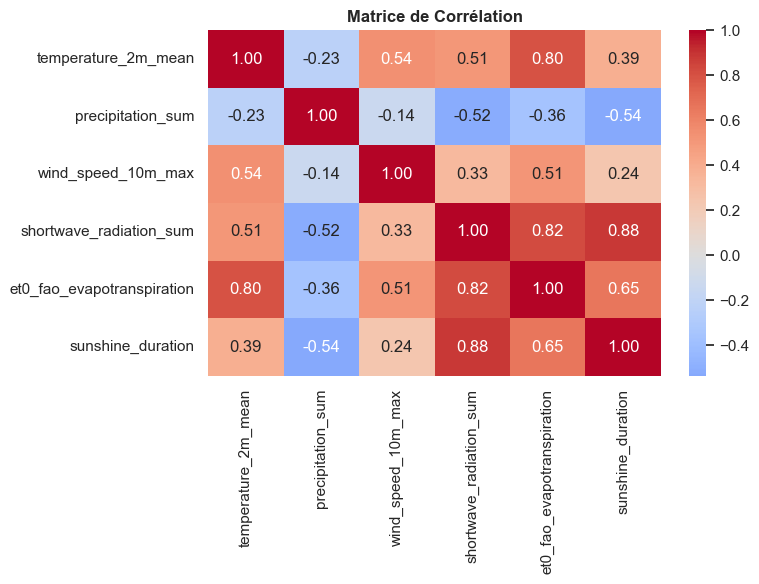

In [6]:
# ── Corrélations entre variables météo ────────────────────────────────────────
corr_cols = ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max',
             'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'sunshine_duration']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation', fontweight='bold')
plt.tight_layout(); plt.show()

<a id="section-cleaning"></a>

---
## 3. 🔧 Nettoyage & Feature Engineering

In [7]:
# ── Variables temporelles ─────────────────────────────────────────────────────
df['year']         = df['time'].dt.year
df['quarter']      = df['time'].dt.quarter
df['day_of_year']  = df['time'].dt.dayofyear
df['month_sin']    = np.sin(2 * np.pi * df['month'] / 12)   # encodage cyclique
df['month_cos']    = np.cos(2 * np.pi * df['month'] / 12)
df['is_dry_season']= df['month'].isin([11,12,1,2,3]).astype(int)

# ── Variables dérivées (indicateurs de pollution potentielle) ─────────────────
df['temp_amplitude']   = df['temperature_2m_max'] - df['temperature_2m_min']
df['sunshine_ratio']   = df['sunshine_duration'] / (df['daylight_duration'] + 1e-6)
df['is_no_wind']       = (df['wind_speed_10m_max'] < 5).astype(int)  # stagnation
df['is_no_rain']       = (df['precipitation_sum'] < 0.1).astype(int)  # pas de lessivage

# ── Variables de lag (séries temporelles) ─────────────────────────────────────
df = df.sort_values(['city', 'time']).reset_index(drop=True)
for lag in [1, 3, 7]:
    df[f'temp_lag{lag}'] = df.groupby('city')['temperature_2m_mean'].shift(lag)
    df[f'wind_lag{lag}'] = df.groupby('city')['wind_speed_10m_max'].shift(lag)

df['temp_roll7'] = df.groupby('city')['temperature_2m_mean'].transform(
    lambda x: x.rolling(7, min_periods=1).mean())

# ── Encodage des catégories ───────────────────────────────────────────────────
df['region_enc'] = df['region'].astype('category').cat.codes
df['city_enc']   = df['city'].astype('category').cat.codes

print(f"Features construites. Nouvelles colonnes : {df.shape[1]} au total")

Features construites. Nouvelles colonnes : 46 au total


In [8]:
df['pm25_proxy'] = (
    0.35 * df['temperature_2m_mean'].fillna(df['temperature_2m_mean'].mean())
    + 0.25 * df['shortwave_radiation_sum'].fillna(0)
    + 0.20 * df['et0_fao_evapotranspiration'].fillna(0)
    + 8.0  * df['is_no_wind']
    + 5.0  * df['is_no_rain']
    + 4.0  * df['is_dry_season']
).clip(lower=0)

print("Proxy PM2.5 — aperçu :")
print(df['pm25_proxy'].describe().round(2))

Proxy PM2.5 — aperçu :
count    87240.00
mean        16.79
std          4.95
min          5.60
25%         13.29
50%         15.19
75%         19.72
max         30.34
Name: pm25_proxy, dtype: float64


<a id="section-baseline"></a>

---
## 4. 🤖 Modélisation Baseline

> **Objectif :** Prédire `pm25_proxy` à partir des variables météorologiques.

In [9]:
# ── Préparation du jeu de données ─────────────────────────────────────────────
FEATURES = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'sunshine_ratio',
    'temp_amplitude', 'is_no_wind', 'is_no_rain', 'is_dry_season',
    'month_sin', 'month_cos', 'day_of_year',
    'temp_lag1', 'temp_lag7', 'wind_lag1', 'temp_roll7',
    'latitude', 'longitude', 'region_enc', 'city_enc'
]
TARGET = 'pm25_proxy'

df_model = df[FEATURES + [TARGET]].copy()

# Remplir les NaN des features de lag (normaux en début de série par ville)
# et les NaN résiduels par la médiane de chaque colonne
for col in FEATURES:
    if df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Ne supprimer que les lignes sans cible
df_model = df_model.dropna(subset=[TARGET])

X, y = df_model[FEATURES], df_model[TARGET]

# Split temporel (80% train, 20% test) — NE PAS utiliser un split aléatoire !
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")


Train : 69,792 | Test : 17,448


In [10]:
# ── Entraînement du modèle ────────────────────────────────────────────────────
model = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=SEED)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Performances :")
print(f"   R²   = {r2_score(y_test, y_pred):.4f}")
print(f"   MAE  = {mean_absolute_error(y_test, y_pred):.4f}")

Performances :
   R²   = 0.9984
   MAE  = 0.0812


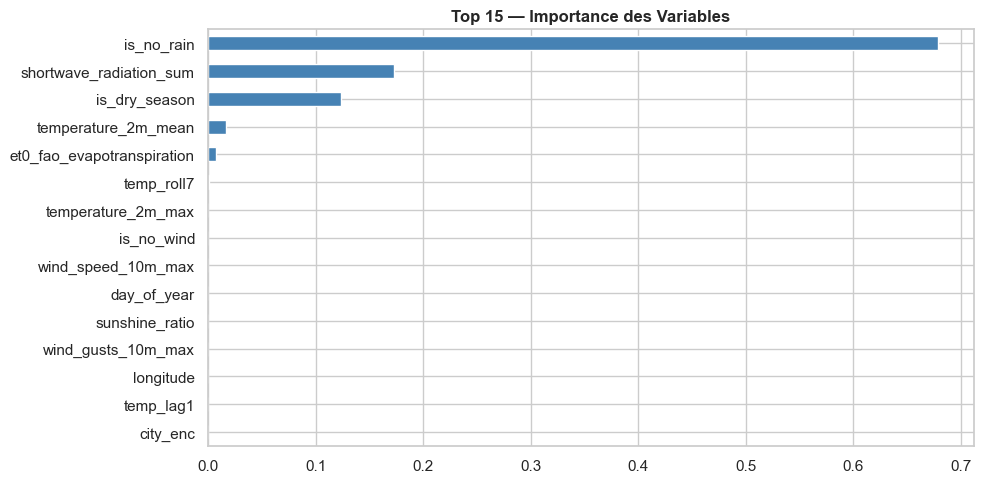

In [11]:
# ── Importance des variables ───────────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 — Importance des Variables', fontweight='bold')
plt.tight_layout(); plt.show()

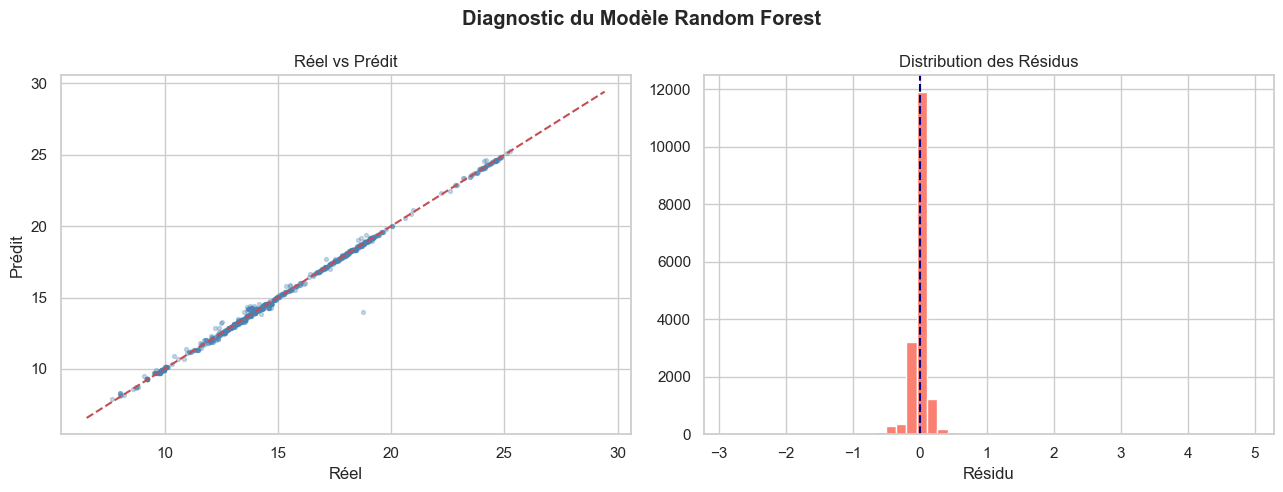

In [12]:
# ── Prédictions vs Réalité ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_test[:1000], y_pred[:1000], alpha=0.3, s=8, color='steelblue')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set(xlabel='Réel', ylabel='Prédit', title='Réel vs Prédit')

# Résidus
axes[1].hist(y_test.values - y_pred, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0, color='navy', lw=1.5, ls='--')
axes[1].set(xlabel='Résidu', title='Distribution des Résidus')

plt.suptitle('Diagnostic du Modèle Random Forest', fontweight='bold')
plt.tight_layout(); plt.show()

<a id="section-further"></a>

---
## 💡 Pour aller plus loin

### ⏱️ Modèles de Séries Temporelles
Prophet, ARIMA, LSTM, Temporal Fusion Transformer, XGBoost/LightGBM avec variables de lag.

### 🗺️ Modèles Spatio-Temporels
Combiner coordonnées GPS et lags temporels (déjà fait ici ✅), ou aller plus loin avec ConvLSTM ou réseaux de neurones graphiques.

> 💡 Une solution simple et bien justifiée vaut mieux qu’un modèle complexe mal compris.

---

<div align='center'>

**Bonne chance ! 🚀🌍**  
*Hackathon IndabaX Cameroon 2026*

</div>


### Utilisation de XGBoost

In [13]:
# ── XGBoost : Preprocessing ───────────────────────────────────────────────────
# XGBoost ne gère pas nativement les colonnes texte (city, region)
# On doit les encoder en nombres avec LabelEncoder

from sklearn.preprocessing import LabelEncoder

df_xgb = df.copy()

# Encodage des colonnes catégorielles
le_city   = LabelEncoder()
le_region = LabelEncoder()

df_xgb['city_enc']   = le_city.fit_transform(df_xgb['city'].astype(str))
df_xgb['region_enc'] = le_region.fit_transform(df_xgb['region'].astype(str))

print("Encodage terminé !")
print(f"  Villes encodées  : {df_xgb['city_enc'].nunique()} valeurs uniques")
print(f"  Régions encodées : {df_xgb['region_enc'].nunique()} valeurs uniques")
df_xgb[['city', 'city_enc', 'region', 'region_enc']].drop_duplicates().head(6)

Encodage terminé !
  Villes encodées  : 40 valeurs uniques
  Régions encodées : 10 valeurs uniques


,city,city_enc,region,region_enc
0,Abong-Mbang,0,Est,2
2181,Akonolinga,1,Centre,1
4362,Ambam,2,Sud,8
6543,Bafia,3,Centre,1
8724,Bafoussam,4,Ouest,7
10905,Bamenda,5,Nord-Ouest,6


In [14]:
# ── XGBoost : Entraînement ────────────────────────────────────────────────────
import xgboost as xgb

# On réutilise exactement les mêmes features que la Random Forest
# pour une comparaison équitable
FEATURES_XGB = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'sunshine_ratio',
    'temp_amplitude', 'is_no_wind', 'is_no_rain', 'is_dry_season',
    'month_sin', 'month_cos', 'day_of_year',
    'temp_lag1', 'temp_lag7', 'wind_lag1', 'temp_roll7',
    'latitude', 'longitude', 'region_enc', 'city_enc'
]
TARGET = 'pm25_proxy'

# Préparation du dataset
df_model_xgb = df_xgb[FEATURES_XGB + [TARGET]].copy()

for col in FEATURES_XGB:
    if df_model_xgb[col].isna().any():
        df_model_xgb[col] = df_model_xgb[col].fillna(df_model_xgb[col].median())

df_model_xgb = df_model_xgb.dropna(subset=[TARGET])

X_xgb = df_model_xgb[FEATURES_XGB]
y_xgb = df_model_xgb[TARGET]

# Split train/test (même SEED pour comparer dans les mêmes conditions)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=SEED
)

# ── Définition du modèle XGBoost ──────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators    = 500,       # Nombre d'arbres (plus que RF car boosting)
    learning_rate   = 0.05,      # Pas d'apprentissage (petit = plus précis)
    max_depth       = 6,         # Profondeur max de chaque arbre
    subsample       = 0.8,       # % des données utilisées par arbre (évite overfitting)
    colsample_bytree= 0.8,       # % des features utilisées par arbre
    reg_alpha       = 0.1,       # Régularisation L1
    reg_lambda      = 1.0,       # Régularisation L2
    random_state    = SEED,
    n_jobs          = -1,        # Utilise tous les cœurs CPU
    verbosity       = 0          # Désactive les messages d'entraînement
)

# ── Entraînement avec early stopping ─────────────────────────────────────────
# Early stopping : arrête l'entraînement si aucune amélioration après 30 tours
# Évite le surapprentissage automatiquement !
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set    = [(X_test_xgb, y_test_xgb)],
    verbose     = False
)

print(f"Modèle XGBoost entraîné !")
print(f"  Nombre d'arbres utilisés : {xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else xgb_model.n_estimators}")

Modèle XGBoost entraîné !
  Nombre d'arbres utilisés : 500


  Performances XGBoost
  R²   = 0.9974
  MAE  = 0.0711


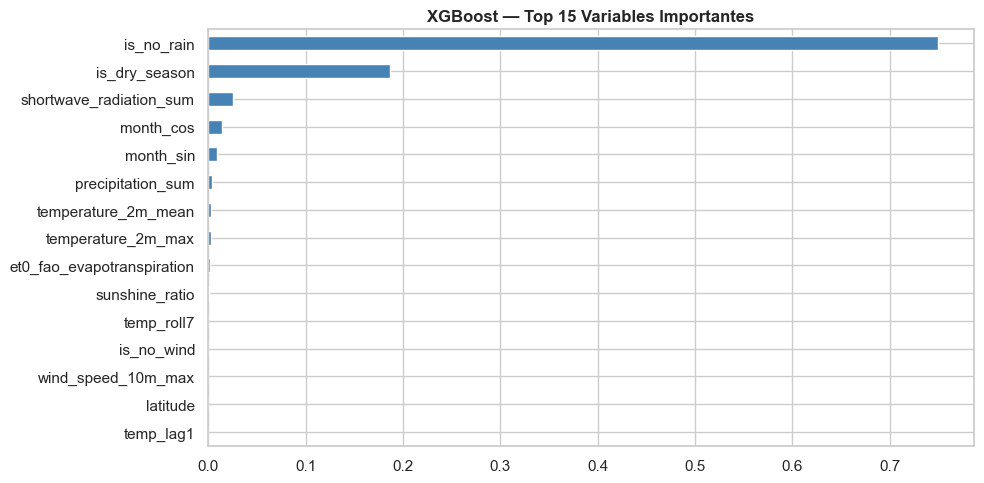

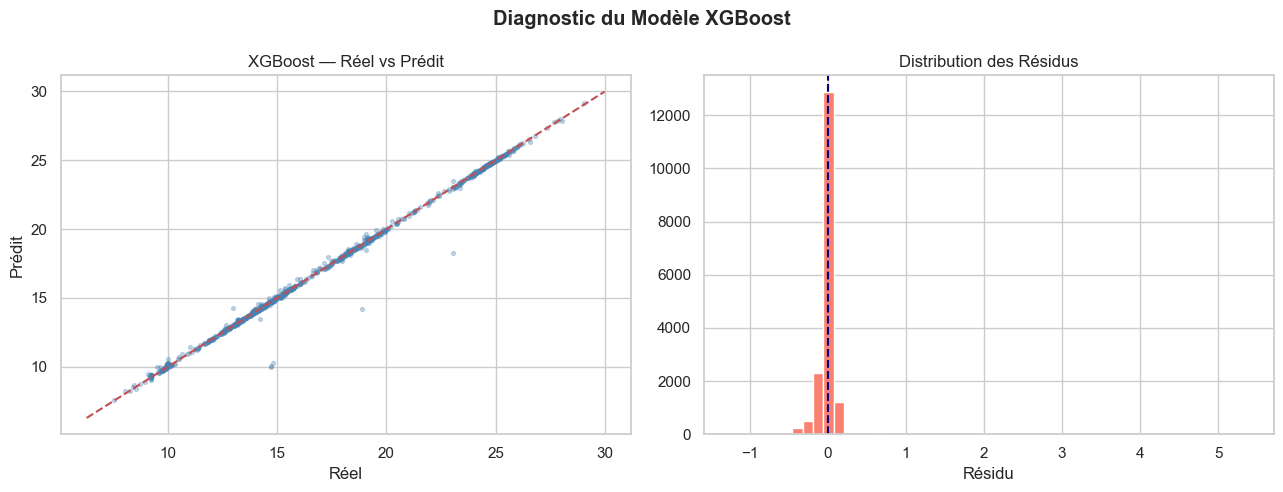

In [15]:
# ── XGBoost : Évaluation complète ────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_xgb = xgb_model.predict(X_test_xgb)

r2_xgb  = r2_score(y_test_xgb, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)

print("=" * 40)
print("  Performances XGBoost")
print("=" * 40)
print(f"  R²   = {r2_xgb:.4f}")
print(f"  MAE  = {mae_xgb:.4f}")
print("=" * 40)

# ── Importance des variables ──────────────────────────────────────────────────
imp_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES_XGB
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
imp_xgb.sort_values().plot(kind='barh', color='steelblue')
plt.title('XGBoost — Top 15 Variables Importantes', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Réel vs Prédit ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_xgb[:1000], y_pred_xgb[:1000],
                alpha=0.3, s=8, color='steelblue')
lim = [min(y_test_xgb.min(), y_pred_xgb.min()),
       max(y_test_xgb.max(), y_pred_xgb.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set(xlabel='Réel', ylabel='Prédit', title='XGBoost — Réel vs Prédit')

axes[1].hist(y_test_xgb.values - y_pred_xgb, bins=50,
             color='salmon', edgecolor='white')
axes[1].axvline(0, color='navy', lw=1.5, ls='--')
axes[1].set(xlabel='Résidu', title='Distribution des Résidus')

plt.suptitle('Diagnostic du Modèle XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

       Modèle     R²    MAE Meilleur R² Meilleur MAE
Random Forest 0.9984 0.0812           ✓             
      XGBoost 0.9974 0.0711                        ✓


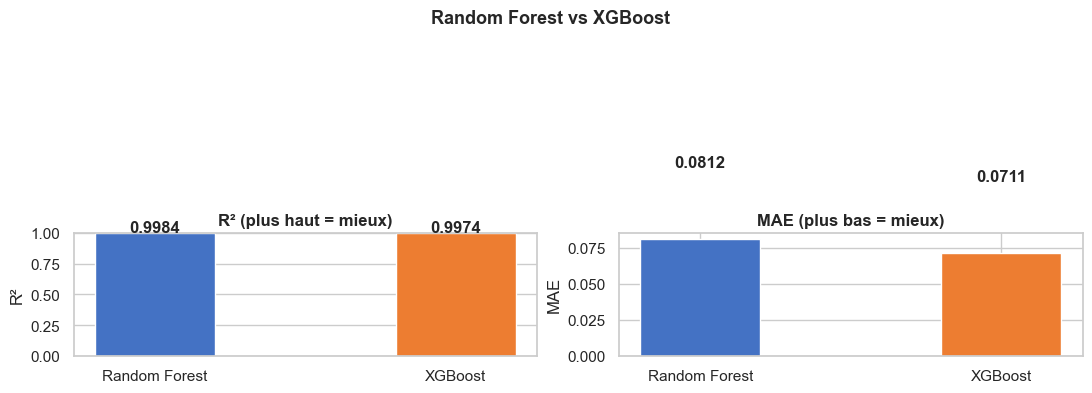


Conclusion : Random Forest est le meilleur modèle
  Différence R²  : +0.0010 en faveur de Random Forest
  Différence MAE : -0.0101 en faveur de Random Forest


In [16]:
# ── Comparaison RF vs XGBoost ─────────────────────────────────────────────────
# Récupération des scores RF déjà calculés dans le notebook de base
r2_rf  = r2_score(y_test, y_pred)       # y_test et y_pred viennent du notebook de base
mae_rf = mean_absolute_error(y_test, y_pred)

# Tableau comparatif
comparaison = pd.DataFrame({
    'Modèle'     : ['Random Forest', 'XGBoost'],
    'R²'         : [round(r2_rf, 4),  round(r2_xgb, 4)],
    'MAE'        : [round(mae_rf, 4), round(mae_xgb, 4)],
    'Meilleur R²': ['✓' if r2_rf > r2_xgb else '', '✓' if r2_xgb > r2_rf else ''],
    'Meilleur MAE':['✓' if mae_rf < mae_xgb else '', '✓' if mae_xgb < mae_rf else ''],
})
print(comparaison.to_string(index=False))

# ── Graphique comparatif ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

modeles = ['Random Forest', 'XGBoost']
couleurs = ['#4472C4', '#ED7D31']

# R²
bars = axes[0].bar(modeles, [r2_rf, r2_xgb], color=couleurs, width=0.4)
axes[0].set_ylim(0, 1)
axes[0].set_title('R² (plus haut = mieux)', fontweight='bold')
axes[0].set_ylabel('R²')
for bar, val in zip(bars, [r2_rf, r2_xgb]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# MAE
bars2 = axes[1].bar(modeles, [mae_rf, mae_xgb], color=couleurs, width=0.4)
axes[1].set_title('MAE (plus bas = mieux)', fontweight='bold')
axes[1].set_ylabel('MAE')
for bar, val in zip(bars2, [mae_rf, mae_xgb]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('Random Forest vs XGBoost', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Conclusion automatique ────────────────────────────────────────────────────
gagnant = "XGBoost" if r2_xgb > r2_rf else "Random Forest"
gain_r2 = abs(r2_xgb - r2_rf)
gain_mae = abs(mae_xgb - mae_rf)

print(f"\nConclusion : {gagnant} est le meilleur modèle")
print(f"  Différence R²  : +{gain_r2:.4f} en faveur de {gagnant}")
print(f"  Différence MAE : -{gain_mae:.4f} en faveur de {gagnant}")

### Utilisation de LightGBM

In [17]:
# ── LightGBM : Preprocessing ──────────────────────────────────────────────────
# AVANTAGE CLÉ de LightGBM : il gère nativement les colonnes catégorielles !
# Pas besoin de LabelEncoder — on lui indique juste quelles colonnes sont catégorielles

import lightgbm as lgb

df_lgb = df.copy()

# On convertit city et region en type 'category' (pandas)
# LightGBM reconnaît ce type automatiquement et l'optimise
df_lgb['city']   = df_lgb['city'].astype('category')
df_lgb['region'] = df_lgb['region'].astype('category')

# On garde les mêmes features que RF et XGBoost
# SAUF city_enc et region_enc — on utilise city et region directement
FEATURES_LGB = [
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'sunshine_ratio',
    'temp_amplitude', 'is_no_wind', 'is_no_rain', 'is_dry_season',
    'month_sin', 'month_cos', 'day_of_year',
    'temp_lag1', 'temp_lag7', 'wind_lag1', 'temp_roll7',
    'latitude', 'longitude',
    'city', 'region'          # Directement en catégoriel — pas d'encodage manuel !
]
TARGET = 'pm25_proxy'

df_model_lgb = df_lgb[FEATURES_LGB + [TARGET]].copy()

for col in FEATURES_LGB:
    if df_model_lgb[col].dtype.name != 'category' and df_model_lgb[col].isna().any():
        df_model_lgb[col] = df_model_lgb[col].fillna(df_model_lgb[col].median())

df_model_lgb = df_model_lgb.dropna(subset=[TARGET])

X_lgb = df_model_lgb[FEATURES_LGB]
y_lgb = df_model_lgb[TARGET]

# Split train/test (même SEED pour comparaison équitable)
X_train_lgb, X_test_lgb, y_train_lgb, y_test_lgb = train_test_split(
    X_lgb, y_lgb, test_size=0.2, random_state=SEED
)

print("Preprocessing terminé !")
print(f"  Train : {X_train_lgb.shape[0]:,} lignes")
print(f"  Test  : {X_test_lgb.shape[0]:,} lignes")
print(f"  Features : {len(FEATURES_LGB)} variables dont 2 catégorielles natives")

Preprocessing terminé !
  Train : 69,792 lignes
  Test  : 17,448 lignes
  Features : 24 variables dont 2 catégorielles natives


In [18]:
# ── LightGBM : Entraînement ───────────────────────────────────────────────────
import lightgbm as lgb
import time

lgb_model = lgb.LGBMRegressor(
    n_estimators      = 1000,      # Beaucoup d'arbres — early stopping s'occupera d'arrêter
    learning_rate     = 0.05,      # Même que XGBoost pour comparaison équitable
    max_depth         = -1,        # -1 = pas de limite (LightGBM gère leaf-wise)
    num_leaves        = 63,        # Complexité de chaque arbre (2^max_depth - 1 = 63 pour depth 6)
    subsample         = 0.8,       # % de lignes par arbre
    colsample_bytree  = 0.8,       # % de features par arbre
    reg_alpha         = 0.1,       # Régularisation L1
    reg_lambda        = 1.0,       # Régularisation L2
    min_child_samples = 20,        # Évite les feuilles avec trop peu d'observations
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1         # Désactive tous les logs
)

# Callbacks : early stopping + affichage tous les 100 tours
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

start = time.time()

lgb_model.fit(
    X_train_lgb, y_train_lgb,
    eval_set          = [(X_test_lgb, y_test_lgb)],
    callbacks         = callbacks
)

duree = time.time() - start

print(f"\nModèle LightGBM entraîné en {duree:.1f} secondes !")
print(f"  Meilleur nombre d'arbres : {lgb_model.best_iteration_}")

[100]	valid_0's l2: 0.033391
[200]	valid_0's l2: 0.0255946
[300]	valid_0's l2: 0.0249973

Modèle LightGBM entraîné en 2.1 secondes !
  Meilleur nombre d'arbres : 316


  Performances LightGBM
  R²   = 0.9990
  MAE  = 0.0595


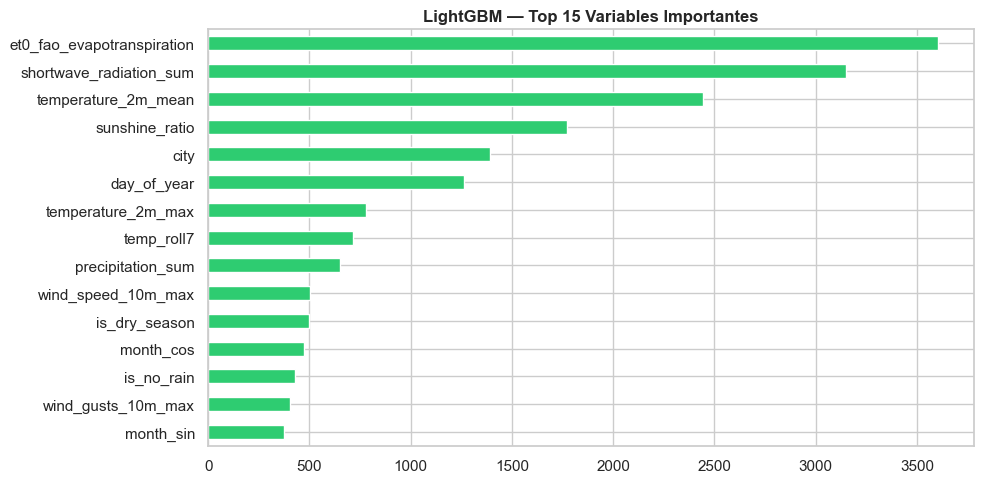

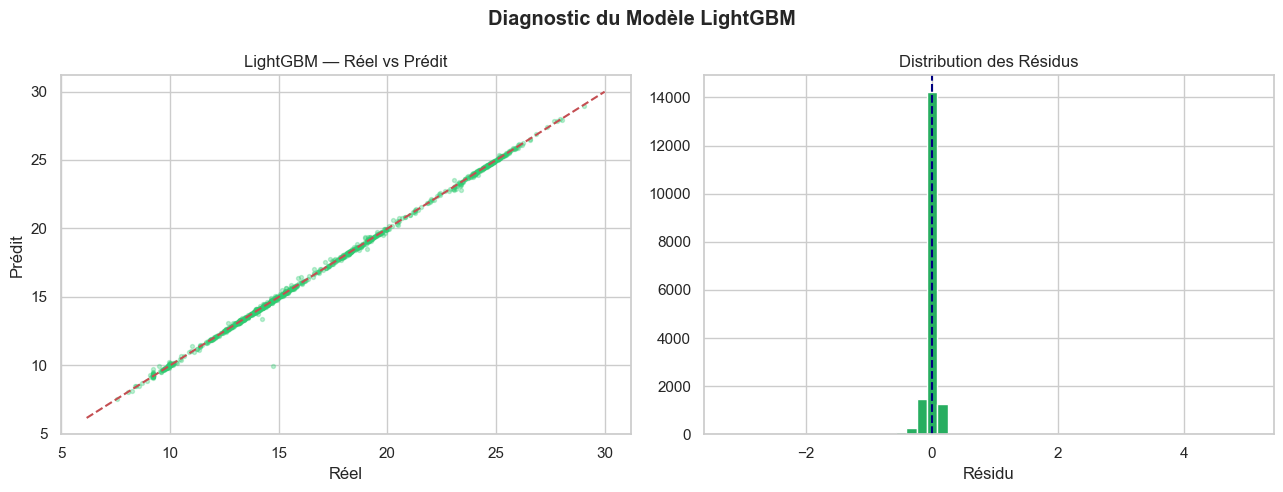

In [19]:
# ── LightGBM : Évaluation complète ───────────────────────────────────────────
y_pred_lgb = lgb_model.predict(X_test_lgb)

r2_lgb  = r2_score(y_test_lgb, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test_lgb, y_pred_lgb)

print("=" * 40)
print("  Performances LightGBM")
print("=" * 40)
print(f"  R²   = {r2_lgb:.4f}")
print(f"  MAE  = {mae_lgb:.4f}")
print("=" * 40)

# ── Importance des variables ──────────────────────────────────────────────────
imp_lgb = pd.Series(
    lgb_model.feature_importances_,
    index=FEATURES_LGB
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
imp_lgb.sort_values().plot(kind='barh', color='#2ecc71')
plt.title('LightGBM — Top 15 Variables Importantes', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Réel vs Prédit ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_lgb[:1000], y_pred_lgb[:1000],
                alpha=0.3, s=8, color='#2ecc71')
lim = [min(y_test_lgb.min(), y_pred_lgb.min()),
       max(y_test_lgb.max(), y_pred_lgb.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set(xlabel='Réel', ylabel='Prédit', title='LightGBM — Réel vs Prédit')

axes[1].hist(y_test_lgb.values - y_pred_lgb, bins=50,
             color='#27ae60', edgecolor='white')
axes[1].axvline(0, color='navy', lw=1.5, ls='--')
axes[1].set(xlabel='Résidu', title='Distribution des Résidus')

plt.suptitle('Diagnostic du Modèle LightGBM', fontweight='bold')
plt.tight_layout()
plt.show()


===== COMPARAISON FINALE =====
       Modèle       R²      MAE  Rang MAE  Rang R²
     LightGBM 0.998988 0.059469         1        1
      XGBoost 0.997409 0.071131         2        3
Random Forest 0.998426 0.081242         3        2

Meilleur modèle (MAE) : LightGBM
Meilleur modèle (R²)  : LightGBM


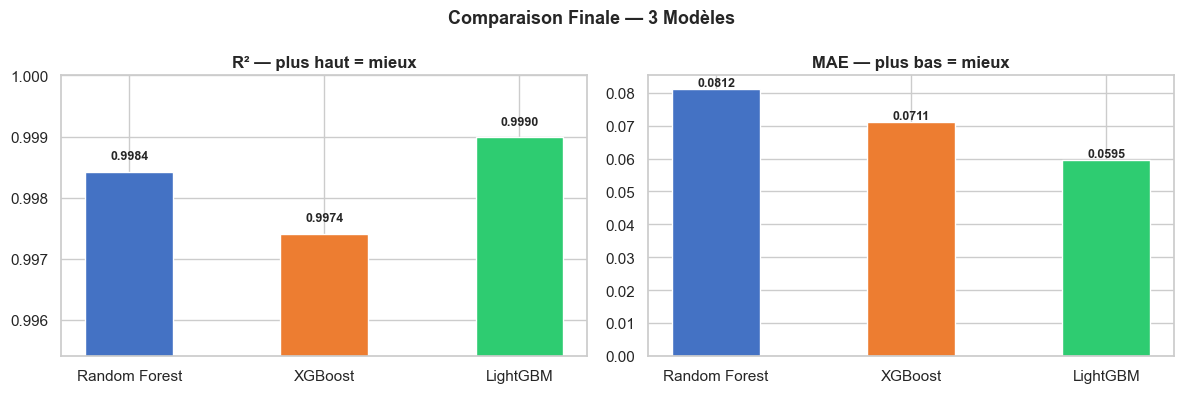

In [20]:
# ── Comparaison finale : RF vs XGBoost vs LightGBM ────────────────────────────

# Scores RF et XGBoost déjà calculés précédemment
r2_rf   = r2_score(y_test, y_pred)
mae_rf  = mean_absolute_error(y_test, y_pred)
# r2_xgb et mae_xgb viennent de la cellule XGBoost

resultats = pd.DataFrame({
    'Modèle'  : ['Random Forest', 'XGBoost', 'LightGBM'],
    'R²'      : [r2_rf,  r2_xgb,  r2_lgb],
    'MAE'     : [mae_rf, mae_xgb, mae_lgb],
})
resultats = resultats.sort_values('MAE').reset_index(drop=True)
resultats['Rang MAE'] = resultats['MAE'].rank().astype(int)
resultats['Rang R²']  = resultats['R²'].rank(ascending=False).astype(int)

print("\n===== COMPARAISON FINALE =====")
print(resultats[['Modèle', 'R²', 'MAE', 'Rang MAE', 'Rang R²']].to_string(index=False))
print(f"\nMeilleur modèle (MAE) : {resultats.iloc[0]['Modèle']}")
print(f"Meilleur modèle (R²)  : {resultats.loc[resultats['R²'].idxmax(), 'Modèle']}")

# ── Graphique comparatif final ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modeles  = ['Random Forest', 'XGBoost', 'LightGBM']
couleurs = ['#4472C4', '#ED7D31', '#2ecc71']
r2s      = [r2_rf,  r2_xgb,  r2_lgb]
maes     = [mae_rf, mae_xgb, mae_lgb]

# R²
bars = axes[0].bar(modeles, r2s, color=couleurs, width=0.45)
axes[0].set_ylim(min(r2s) - 0.002, 1.0)
axes[0].set_title('R² — plus haut = mieux', fontweight='bold')
for bar, val in zip(bars, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# MAE
bars2 = axes[1].bar(modeles, maes, color=couleurs, width=0.45)
axes[1].set_title('MAE — plus bas = mieux', fontweight='bold')
for bar, val in zip(bars2, maes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison Finale — 3 Modèles', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# ── Sauvegarde du modèle LightGBM avec joblib ─────────────────────────────────
import joblib
import os

# Créer un dossier models/ si il n'existe pas
os.makedirs('../models', exist_ok=True)

# Sauvegarder le modèle
joblib.dump(lgb_model, '../models/lightgbm_pm25.pkl')

print("Modèle sauvegardé avec succès !")
print(f"  Emplacement : ../models/lightgbm_pm25.pkl")
print(f"  Taille      : {os.path.getsize('../models/lightgbm_pm25.pkl') / 1024:.1f} Ko")


Modèle sauvegardé avec succès !
  Emplacement : ../models/lightgbm_pm25.pkl
  Taille      : 1812.0 Ko


In [22]:
# ── Vérification : on recharge le modèle et on refait une prédiction ──────────
model_charge = joblib.load('../models/lightgbm_pm25.pkl')

# Test sur les 5 premières lignes du jeu de test
test_sample  = X_test_lgb.iloc[:5]
pred_original = lgb_model.predict(test_sample)
pred_charge   = model_charge.predict(test_sample)

print("Vérification chargement du modèle :")
print(f"{'Prédiction originale':<25} {'Prédiction rechargée':<25} {'Identique ?'}")
print("-" * 65)
for orig, charg in zip(pred_original, pred_charge):
    ok = "✓" if abs(orig - charg) < 1e-6 else "✗"
    print(f"{orig:<25.6f} {charg:<25.6f} {ok}")

print("\nModèle prêt à être utilisé dans le dashboard !")

Vérification chargement du modèle :
Prédiction originale      Prédiction rechargée      Identique ?
-----------------------------------------------------------------
10.097984                 10.097984                 ✓
13.726054                 13.726054                 ✓
13.918191                 13.918191                 ✓
14.454573                 14.454573                 ✓
13.122964                 13.122964                 ✓

Modèle prêt à être utilisé dans le dashboard !
